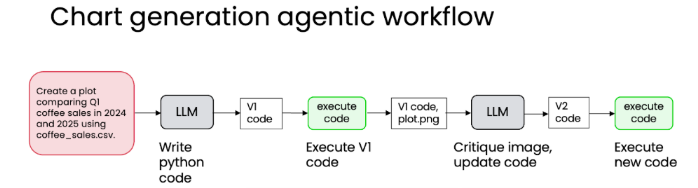

# Loading and preparing the dataset

In [1]:
import pandas as pd
df = pd.read_csv('coffee_sales.csv')
df.sample(5)

,date,time,cash_type,card,price,coffee_name
2761,2025-01-12,14:04,card,ANON-0000-0000-0012,3.086,Americano with Milk
3114,2025-02-16,13:58,card,ANON-0000-0000-1196,3.576,Latte
2177,2024-11-01,09:49,card,ANON-0000-0000-0612,3.576,Latte
3145,2025-02-18,10:52,card,ANON-0000-0000-1215,2.596,Americano
662,2024-05-31,14:33,card,ANON-0000-0000-0250,3.772,Latte


In [2]:
# Adding quarter, month and year columns
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["quarter"] = df["date"].dt.quarter
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df.sample(5)

,date,time,cash_type,card,price,coffee_name,quarter,month,year
800,2024-06-16,16:05,card,ANON-0000-0000-0306,3.772,Hot Chocolate,2,6,2024
1611,2024-09-20,14:44,card,ANON-0000-0000-0643,2.302,Americano,3,9,2024
3184,2025-02-20,10:42,card,ANON-0000-0000-1163,2.596,Americano,1,2,2025
3601,2025-03-21,07:40,card,ANON-0000-0000-1110,2.596,Americano,1,3,2025
3195,2025-02-21,06:03,card,ANON-0000-0000-1163,2.596,Americano,1,2,2025


# Building the pipeline

## 1. Generate code to create version 1 chart

In [3]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
openai_client = OpenAI(api_key=openai_api_key)

# Helper function to call openai model
def get_response(prompt:str) -> str:
    response = openai_client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
    )
    return response.output_text

In [4]:
# Function to generate version 1 chart code
import re
def generate_chart_code(instruction: str, out_path_v1: str) -> str:
    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date   (datetime64 — already parsed; use df['date'].dt.year, df['date'].dt.month, etc.)
    - time   (string, HH:MM — do NOT concatenate or combine with the date column)
    - cash_type (string: 'card' or 'cash')
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (int, 1-4 — already computed, use directly)
    - month  (int, 1-12 — already computed, use directly)
    - year   (int, e.g. 2024 — already computed, use directly)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    8. CRITICAL: 'date' is datetime64 — never use string concatenation on it.
       Filter by year/quarter using the 'year' and 'quarter' integer columns.
    
    Return ONLY the code wrapped in <execute_python> tags.
    """
    
    # Prompt model to generate code
    response = get_response(prompt)
    
    # Extract code between <execute_python> tags
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", response)
    code = match.group(1).strip()
    print("Extracted code :- ")
    print(code)
    
    # Execute code
    exec_globals = {"df": df}
    exec(code, exec_globals)
    
    return code

In [5]:
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    out_path_v1="chart_v1.png"
)

Extracted code :- 
import pandas as pd
import matplotlib.pyplot as plt

# Filter DataFrame for Q1 sales in 2024 and 2025
df_q1_2024 = df[(df['year'] == 2024) & (df['quarter'] == 1)]
df_q1_2025 = df[(df['year'] == 2025) & (df['quarter'] == 1)]

# Group by coffee_name and sum the prices
sales_2024 = df_q1_2024.groupby('coffee_name')['price'].sum()
sales_2025 = df_q1_2025.groupby('coffee_name')['price'].sum()

# Create a comparison DataFrame
sales_comparison = pd.DataFrame({
    '2024': sales_2024,
    '2025': sales_2025
}).fillna(0)

# Plotting
sales_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Q1 Coffee Sales Comparison (2024 vs 2025)')
plt.xlabel('Coffee Name')
plt.ylabel('Total Sales ($)')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_v1.png', dpi=300)
plt.close()


(np.float64(-0.5), np.float64(2999.5), np.float64(1799.5), np.float64(-0.5))

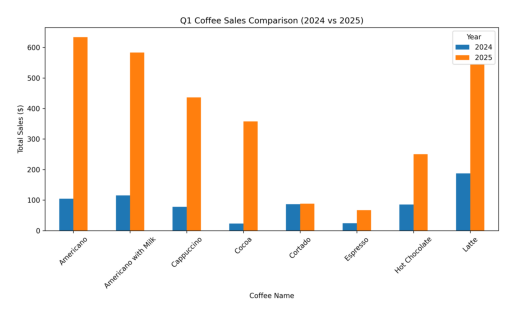

In [6]:
# Display version 1 plot
import matplotlib.pyplot as plt
img = plt.imread("chart_v1.png")
plt.imshow(img)
plt.axis("off")

## 2. Reflect on the output and create version 2 chart

In [7]:
import base64

# Helper function to convert png image to base64
def encode_image_b64(path: str) -> tuple[str, str]:
    media_type = "image/png"
    
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    
    return media_type, b64

In [8]:
# Helper function to call openai vision model
def image_openai_call(prompt: str, media_type: str, b64:str) -> str:
    data_url = f"data:{media_type};base64,{b64}"
    response = openai_client.responses.create(
        model="o4-mini",
        input=[
            {
                "role":"user",
                "content":[
                    {"type": "input_text", "text":prompt},
                    {"type": "input_image", "image_url":data_url}
                ],
            }
        ],
    )
    return response.output_text

In [9]:
# Function to reflect on version 1 chart
def reflect_on_image_and_regenerate(chart_path: str, instruction:str, out_path_v2: str, code_v1: str) -> tuple[str, str]:
    # Convert image to base64
    media_type, b64 = encode_image_b64(chart_path)
    
    prompt =  f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.
    
    IMPORTANT: The 'date' column is already a pandas datetime64 type.
    - Do NOT concatenate 'date' with 'time' using string operations.
    - To filter by year/quarter, use: df[df['year'] == 2024] or df['date'].dt.year == 2024
    - The 'quarter' and 'year' columns already exist as integers; use them directly.

    Schema (columns available in df):
    - date   (datetime64 — already parsed; use df['date'].dt.year, etc.)
    - time   (string, HH:MM — do NOT concatenate with date)
    - cash_type (string: 'card' or 'cash')
    - card   (string)
    - price  (float)
    - coffee_name (string)
    - quarter (int, 1-4)
    - month  (int, 1-12)
    - year   (int)
    
    CRITICAL TYPE RULE: 'date' is already datetime64.
    - NEVER do: df['date'] + ' ' + df['time']  ← this will crash
    - ALWAYS filter by year/quarter using the integer columns: df[df['year'] == 2024]

    Instruction:
    {instruction}
    """
    # Prompt model to reflect on v1 code and plot
    content = image_openai_call(prompt, media_type, b64)
    
    # Extract feedback on V1 chart
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""
    print(json_line)
    
    # Extract code between <execute_python> tags
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code = match.group(1).strip()
    print("Extracted code :- ")
    print(refined_code)
    
    # Execute code
    exec_globals = {"df": df}
    exec(refined_code, exec_globals)
    
    return json_line, refined_code
    

In [10]:
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv",
    out_path_v2="chart_v2.png",
    code_v1=code_v1
)

{"feedback": "Original code correctly filters and aggregates data, but using DataFrame.plot limits customization. Axis labels overlap slightly and the plot lacks gridlines. Manually positioning bars allows precise control of bar widths, colors, edgecolors, and gridlines for improved readability. Ensuring a consistent category order and fill of missing values also helps maintain clarity."}
Extracted code :- 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Filter and aggregate
df_q1_2024 = df[(df['year'] == 2024) & (df['quarter'] == 1)]
df_q1_2025 = df[(df['year'] == 2025) & (df['quarter'] == 1)]

sales_2024 = df_q1_2024.groupby('coffee_name')['price'].sum()
sales_2025 = df_q1_2025.groupby('coffee_name')['price'].sum()

# Combine into one DataFrame and fill missing
sales_comparison = pd.DataFrame({
    '2024': sales_2024,
    '2025': sales_2025
}).reindex(sorted(set(sales_2024.index) | set(sales_2025.index))).fillna(0)

# Plot
coffees = sales_comparison.index.to

(np.float64(-0.5), np.float64(2999.5), np.float64(1799.5), np.float64(-0.5))

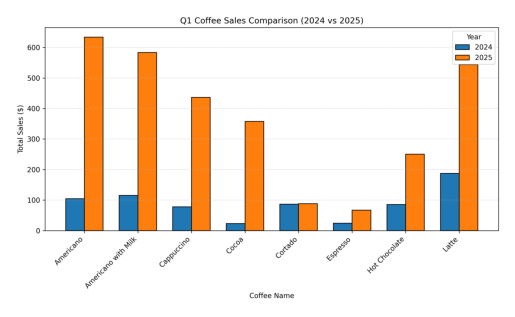

In [11]:
# Display version 2 plot
img = plt.imread("chart_v2.png")
plt.imshow(img)
plt.axis("off")

## 3. Creating the end-to-end workflow

In [12]:
def run_workflow(dataset_path:str, user_instructions:str, image_basename:str="chart"):
    # 1. Load dataset
    df = dataset_path
    
    # 2. Paths to store charts
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"
    
    # 3. Generate V1 code and chart
    print("Version 1 :-")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        out_path_v1=out_v1,
    )
    
    # 4. Display V1 chart
    img = plt.imread(out_v1)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
    # 5. Generate V2 code and chart
    print("Version 2 :-")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        out_path_v2=out_v2,
        code_v1=code_v1
    )
    
    # 4. Display V2 chart
    img = plt.imread(out_v2)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }

Version 1 :-
Extracted code :- 
import pandas as pd
import matplotlib.pyplot as plt

# Filter data for Q1 sales of the years 2024 and 2025
filtered_df = df[(df['quarter'] == 1) & (df['year'].isin([2024, 2025]))]

# Group by coffee_name and year, summing the prices for comparison
q1_sales = filtered_df.groupby(['coffee_name', 'year'])['price'].sum().unstack()

# Plotting
plt.figure(figsize=(10, 6))
q1_sales.plot(kind='bar', stacked=False)
plt.title('Q1 Coffee Sales Comparison: 2024 vs 2025')
plt.xlabel('Coffee Name')
plt.ylabel('Total Sales Price')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig('drink_sales_v1.png', dpi=300)

# Close all plots
plt.close()


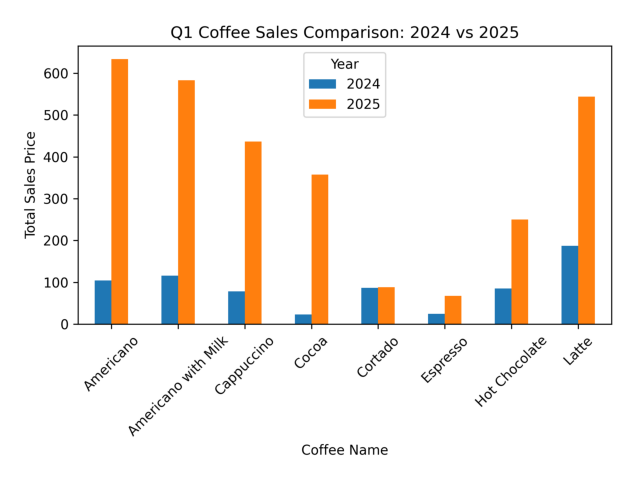

Version 2 :-
{"feedback":"The plot relies on pandas’ .plot wrapper, which limits customization: x-axis labels are still cluttered, there are no gridlines for easier value comparison, and the default color palette is generic. Manual bar positioning, sorted categories, custom colors, and a y-axis gridline would enhance readability and insight."}
Extracted code :- 
import pandas as pd
import matplotlib.pyplot as plt

# Filter for Q1 sales in 2024 and 2025
q1_data = df[(df['quarter'] == 1) & (df['year'].isin([2024, 2025]))]

# Aggregate total sales by coffee_name and year
sales = (
    q1_data
    .groupby(['coffee_name', 'year'])['price']
    .sum()
    .unstack(fill_value=0)
)

# Sort coffee names by 2025 sales descending for insight
sales = sales.sort_values(by=2025, ascending=False)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
indices = range(len(sales))
bar_width = 0.35

ax.bar(
    [i - bar_width/2 for i in indices],
    sales[2024],
    width=bar_width,
    color='#1f77b4',
 

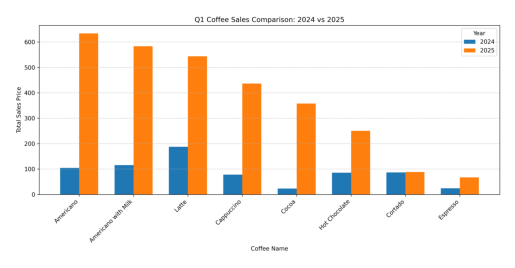

In [13]:
outputs = run_workflow(
    dataset_path=df,
    user_instructions="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    image_basename="drink_sales"
)